# New try
# Assignment: Analyzing Financial Transactions Data from Kafka Topic `fhtw-topic`

In this assignment, you will analyze financial transactions data coming from the Kafka topic `stock-transactions`. The data represents stock trade transactions, including details such as the side of the trade (buy or sell), the quantity of stocks, the stock symbol, the price, the account, and the user ID.

You will perform the following tasks:
1. Set up a Spark session and configure the necessary Kafka parameters.
2. Read the streaming data from the Kafka topic.
3. Parse the JSON data and create a structured DataFrame.
4. Perform simple analysis tasks on the data, such as calculating the total quantity of stocks traded, counting the number of trades for each stock symbol, and calculating the total value of trades for each account.

### Data Structure

The messages in the Kafka topic have the following JSON structure:

```json
{
  "side": "SELL",
  "quantity": 1587,
  "symbol": "ZVV",
  "price": 326,
  "account": "LMN456",
  "userid": "User_5"
}

In [1]:
# Kafka configuration parameters for Confluent Cloud
kafka_params = {
    "kafka.bootstrap.servers": "46.225.20.89:9092",
    "subscribe": "fhtw-stocks",
    "kafka.security.protocol": "PLAINTEXT",
    "startingOffsets": "latest",
}

In [5]:
from pyspark.sql import SparkSession

# include for both already the needed functions for solving the tasks
from pyspark.sql.functions import (
    col, from_json, lit, sum as _sum, count, avg,
    round as _round
)
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType
)

import time

spark = SparkSession.builder \
    .appName("KafkaSparkStreamingExample") \
    .config("spark.jars.packages",
             "org.apache.spark:spark-sql-kafka-0-10_2.12:3.4.0,"
             "org.postgresql:postgresql:42.7.3"
             ) \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

26/06/07 22:53:46 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [8]:
# JSON Schema

schema = StructType([
    StructField("side",     StringType(),  True),   # "BUY" | "SELL"
    StructField("quantity", IntegerType(), True),   # number of shares
    StructField("symbol",   StringType(),  True),   # stock ticker, e.g. "ZVV"
    StructField("price",    DoubleType(),  True),   # price per share
    StructField("account",  StringType(),  True),   # account ID
    StructField("userid",   StringType(),  True),   # user ID
])

In [11]:
# Read streaming data from Kafka
raw_df = spark \
    .readStream \
    .format("kafka") \
    .options(**kafka_params) \
    .load()

In [12]:
# Kafka delivers the payload in the binary `value` column → cast to string,
# then parse as JSON using the schema defined above.
parsed_df = (
    raw_df
    .select(col("value").cast("string").alias("json_str"))
    .select(from_json(col("json_str"), schema).alias("data"))
    .select("data.*")
    # Derived column reused across aggregations: trade_value = quantity × price
    .withColumn("trade_value", col("quantity") * col("price"))
)

In [17]:
# data check
parsed_df

DataFrame[side: string, quantity: int, symbol: string, price: double, account: string, userid: string, trade_value: double]

At this point we have a structured streaming DataFrame:

side | quantity | symbol | price | account | userid | trade_value

### Perform Simple Analysis Tasks

The results should be aggregated and written all together into a postgres table, format: groupname_tradereports:

1.	Determine the Most Traded Stock Symbol (by Volume)
2.	Identify the Stock Symbol with the Highest Average Trade Value
3.	Calculate the Total Number of SELL Trades for Each Stock
4.	Find the Account with the Largest Cumulative Trade Value
5.	Calculate the Average Quantity of Stocks Traded per Symbol

0. Before starting the Spark streaming job, create the target table for trade reports

CREATE TABLE IF NOT EXISTS groupname_tradereports (
    id            SERIAL PRIMARY KEY,
    analysis_type VARCHAR(60)  NOT NULL,  -- identifies which of the 5 analyses
    group_key     VARCHAR(60)  NOT NULL,  -- stock symbol or account ID
    metric_value  NUMERIC(18,2),          -- the computed aggregate
    inserted_at   TIMESTAMPTZ  NOT NULL DEFAULT NOW()
);

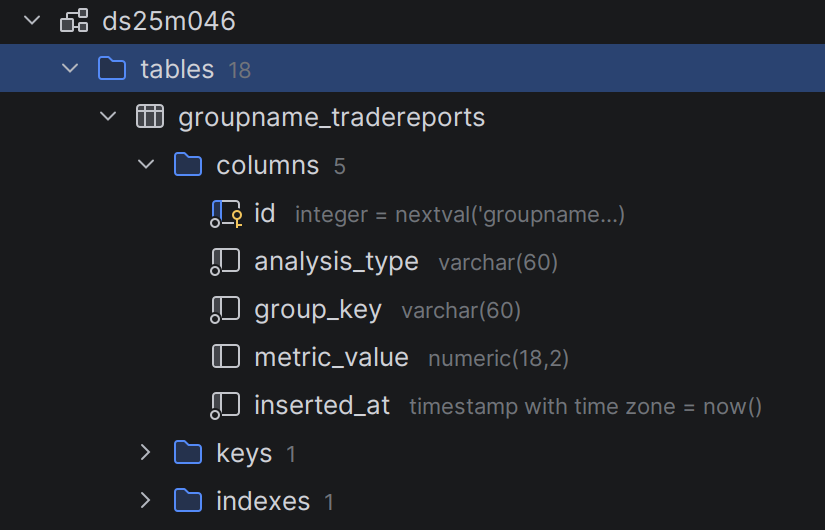

1. Determine the Most Traded Stock Symbol (by Volume) = SUM of quantity

In [18]:
most_traded = (
    parsed_df
    .groupBy("symbol")
    .agg(_sum("quantity").cast("double").alias("metric_value"))
    .withColumn("analysis_type", lit("1_most_traded_by_volume"))
    .withColumn("group_key",     col("symbol"))
)

In [23]:
# Output
most_traded_query = (
    most_traded.writeStream
        .outputMode("complete")
        .format("console")
        .option("truncate", False)
        .start()
)


26/06/07 23:06:34 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-30c13f08-18f0-4698-8c0b-c357c1f1f5ce. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/06/07 23:06:35 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


26/06/07 23:06:35 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


-------------------------------------------
Batch: 0
-------------------------------------------
+------+------------+-------------+---------+
|symbol|metric_value|analysis_type|group_key|
+------+------------+-------------+---------+
+------+------------+-------------+---------+



2.	Identify the Stock Symbol with the Highest Average Trade Value

In [24]:
avg_trade_value = (
    parsed_df
    .groupBy("symbol")
    .agg(_round(avg("trade_value"), 2).alias("metric_value"))
    .withColumn("analysis_type", lit("2_highest_avg_trade_value"))
    .withColumn("group_key",     col("symbol"))
)

3.	Calculate the Total Number of SELL Trades for Each Stock

In [25]:
sell_trades = (
    parsed_df
    .filter(col("side") == "SELL")
    .groupBy("symbol")
    .agg(count("*").cast("double").alias("metric_value"))
    .withColumn("analysis_type", lit("3_total_sell_trades_per_stock"))
    .withColumn("group_key",     col("symbol"))
)

4. Find the Account with the Largest Cumulative Trade Value

In [26]:
account_trade_value = (
    parsed_df
    .groupBy("account")
    .agg(_round(_sum("trade_value"), 2).alias("metric_value"))
    .withColumn("analysis_type", lit("4_largest_cumulative_trade_value"))
    .withColumn("group_key",     col("account"))
)

5.	Calculate the Average Quantity of Stocks Traded per Symbol

In [27]:
avg_qty_per_symbol = (
    parsed_df
    .groupBy("symbol")
    .agg(_round(avg("quantity"), 2).alias("metric_value"))
    .withColumn("analysis_type", lit("5_avg_quantity_per_symbol"))
    .withColumn("group_key",     col("symbol"))
)

6. Union All Results into a Single DataFrame

In [28]:
combined_df = (
    most_traded        .select("analysis_type", "group_key", "metric_value")
    .union(avg_trade_value    .select("analysis_type", "group_key", "metric_value"))
    .union(sell_trades        .select("analysis_type", "group_key", "metric_value"))
    .union(account_trade_value.select("analysis_type", "group_key", "metric_value"))
    .union(avg_qty_per_symbol .select("analysis_type", "group_key", "metric_value"))
)

7. PostgreSQL Connection Properties  (Azure Database for PostgreSQL)

In [29]:
pg_url = (
    "jdbc:postgresql://fhtw-big-data.postgres.database.azure.com:5432/nyt_import"
    "?sslmode=require"
)
pg_props = {
    "user":     "ds25m046",
    "password": "Technikum2025!",
    "driver":   "org.postgresql.Driver",
}
PG_TABLE = "groupname_tradereports"

8. Write Stream → PostgreSQL via foreachBatch

In [30]:
def write_to_postgres(batch_df, batch_id):
    """
    Called once per micro-batch by Spark Structured Streaming.
    Appends the latest aggregated results to the PostgreSQL target table.
    """
    if batch_df.count() == 0:
        print(f"[Batch {batch_id}] Empty batch – skipping.")
        return

    print(f"[Batch {batch_id}] Writing {batch_df.count()} rows to {PG_TABLE} ...")
    batch_df.write.jdbc(url=pg_url, table=PG_TABLE, mode="append", properties=pg_props)
    print(f"[Batch {batch_id}] Done.")


query = (
    combined_df
    .writeStream
    .outputMode("complete")           # required for stateful GROUP BY aggregations
    .option("checkpointLocation", "/tmp/checkpoints/stock_analysis")
    .foreachBatch(write_to_postgres)
    .trigger(processingTime="30 seconds")
    .start()
)

print("Streaming query started – waiting for data …")
query.awaitTermination()


26/06/07 23:12:31 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Streaming query started – waiting for data …


26/06/07 23:12:32 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
26/06/07 23:18:40 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 30000 milliseconds, but spent 367919 milliseconds


[Batch 0] Empty batch – skipping.


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/socket.py", line 718, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 